# <u><center> DATA CLEANING – patient_precriptions.csv </center></u>

## 1. Dataset Overview

**Dataset:** `patient_precriptions.csv`
This dataset is a **patient–medication table** from the hospitalized heart-failure project. Each row associates an `inpatient_number` with one recorded `drug_name`. A patient can appear in several rows because multiple medications can be recorded for the same inpatient.

**Initial profile of the supplied CSV:** **15,362 medication rows × 2 columns**, with **2,007 distinct inpatient numbers** and **25 distinct medication labels**. 

**Cleaning objective:** Keep all valid patient–medication relationships, standardize obvious text presentation inconsistencies, document quality checks, and export cleaned CSV file.

### 2a. Import libraries

**Reason:** Use `pandas` to clean patient–medication records, `matplotlib` to visualize category counts, `json` to save a machine-readable before/after summary, and `Path` for portable file paths.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import json
from pathlib import Path

**Actual Insight:** The notebook uses standard libraries and keeps all cleaning logic inside reproducible Jupyter cells.

### 2b. Define project folders

**Reason:** Separate raw inputs from cleaned outputs. Resolve the project root automatically when the notebook is launched from either the project root or its `notebooks` folder, without embedding someone else’s Windows path.

In [40]:
# Define the main project folder
project_folder = Path(
    r"C:\Users\swith\OneDrive\Desktop\Swithi\Numpy Ninja\Python Hackathon Sept 2026\Python_Hackathon_Sep_2026\cardiac_failure"
)

# Define the folder containing the original datasets
raw_data_folder = project_folder / "raw_data"

# Define the folder for cleaned datasets and reports
output_folder = project_folder / "cleaned_data"

# Create the output folder if it does not already exist
output_folder.mkdir(exist_ok=True)

print("Project Folder:\n", project_folder)
print("Raw Data Folder:\n", raw_data_folder)
print("Output Folder:\n", output_folder)

Project Folder:
 C:\Users\swith\OneDrive\Desktop\Swithi\Numpy Ninja\Python Hackathon Sept 2026\Python_Hackathon_Sep_2026\cardiac_failure
Raw Data Folder:
 C:\Users\swith\OneDrive\Desktop\Swithi\Numpy Ninja\Python Hackathon Sept 2026\Python_Hackathon_Sep_2026\cardiac_failure\raw_data
Output Folder:
 C:\Users\swith\OneDrive\Desktop\Swithi\Numpy Ninja\Python Hackathon Sept 2026\Python_Hackathon_Sep_2026\cardiac_failure\cleaned_data


**Actual Insight:** The source file is read from the raw-data location and all new files are written to a separate `cleaned_data` directory; this preserves the original CSV.

## 3. Cleaning Steps

### 3.1. Load dataset and keep an untouched original

**Reason:** Inspect the actual CSV before changing it and take an original snapshot. A preserved original supports exact before/after row and column comparisons and protects against accidental data loss.

In [46]:

# Read the original Labs dataset
df = pd.read_csv(raw_data_folder / "patient_precriptions.csv")

# Keep an original copy
df_original = df.copy()

# Display the first five records
display(df.head())

print("\n Rows:", df.shape[0])
print("\n Columns:", df.shape[1])
print("\n ")
df.head()
df.info()
df.describe()

,inpatient_number,drug_name
0,857781,sulfotanshinone sodium injection
1,857781,Furosemide tablet
2,857781,Enoxaparin Sodium injection
3,857781,Meglumine Adenosine Cyclophosphate for injection
4,857781,Furosemide injection



 Rows: 15362

 Columns: 2

 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15362 entries, 0 to 15361
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   inpatient_number  15362 non-null  int64 
 1   drug_name         15362 non-null  object
dtypes: int64(1), object(1)
memory usage: 240.2+ KB


,inpatient_number
count,15362.000000
mean,798892.435295
std,41066.780871
min,722128.000000
25%,764993.000000
50%,799246.000000
75%,830868.000000
max,905720.000000


**Actual Insight:** The CSV contains **15,362 rows and 2 columns** (`inpatient_number`, `drug_name`). The first column is numeric and the second is a text medication label. One row describes **one patient–drug association**, not one patient.

### 3.2. Check Column Name and patient–drug association 

**Reason:** Duplicate or padded column names make cross-file joins fragile.

In [48]:
expected_columns = ["inpatient_number", "drug_name"]
print("\n Actual columns:", df.columns.tolist())
print("\n Columns with leading/trailing spaces:",
      [col for col in df.columns if col != col.strip()])
print("\n Repeated column names:", int(df.columns.duplicated().sum()))
print("\n Column data types:", df.dtypes.astype(str).to_dict())
assert df.columns.tolist() == expected_columns, "Review unexpected column names before proceeding."


 Actual columns: ['inpatient_number', 'drug_name']

 Columns with leading/trailing spaces: []

 Repeated column names: 0

 Column data types: {'inpatient_number': 'int64', 'drug_name': 'object'}


**Actual Insight:** Both columns are present in the expected order; there are **0 padded column names** and **0 duplicated column headers**. No column renaming is needed.

### 3.3. Check duplicates

**Reason:** A repeated `inpatient_number` is expected in this one-to-many table. Only an **identical patient–drug pair** can be considered a potential duplicate here.

In [49]:
exact_duplicate_rows = int(df.duplicated().sum())
duplicate_patient_drug_pairs = int(df.duplicated(
    subset=["inpatient_number", "drug_name"]).sum())
repeated_patient_ids = int(df["inpatient_number"].duplicated().sum())
unique_patient_count = int(df["inpatient_number"].nunique())

print("\n Exact duplicated rows:", exact_duplicate_rows)
print("\n Duplicated patient–drug pairs:", duplicate_patient_drug_pairs)
print("\n Repeated patient IDs (expected):", repeated_patient_ids)
print("\n Distinct inpatients:", unique_patient_count)

# Delete identical rows only if they exist; keep different drugs for the same patient.
df = df.drop_duplicates().copy()
print("\n Rows after exact duplicate check:", len(df))


 Exact duplicated rows: 0

 Duplicated patient–drug pairs: 0

 Repeated patient IDs (expected): 13355

 Distinct inpatients: 2007

 Rows after exact duplicate check: 15362


**Actual Insight:** There are **0 exact duplicate rows** and **0 duplicate patient–drug pairs**. The **13,355 repeated patient IDs** reflect patients with multiple drug rows; **no records were removed**. There are **2,007 distinct inpatients** in this CSV.

### 3.4. Missing and blank values

**Reason:** An absent patient ID would block trustworthy joins; a blank `drug_name` would not establish a medication. Distinguish Pandas nulls from empty or whitespace-only text rather than assuming a dataset with no `NaN` has no text-quality concerns.

In [50]:
original_missing_report = pd.DataFrame({
    "missing_count": df_original.isna().sum(),
    "missing_percent": (df_original.isna().mean() * 100).round(2)
})
blank_drug_rows = int(df["drug_name"].astype("string").str.strip().eq("").sum())

print("\n Missing values by column:")
display(original_missing_report)
print("\n Blank / spaces-only medication names:", blank_drug_rows)
print("\n Rows with missing ID:", int(df["inpatient_number"].isna().sum()))
print("\n Rows with missing medication:", int(df["drug_name"].isna().sum()))


 Missing values by column:


,missing_count,missing_percent
inpatient_number,0,0.0
drug_name,0,0.0



 Blank / spaces-only medication names: 0

 Rows with missing ID: 0

 Rows with missing medication: 0


**Actual Insight:** **0 null values** in either column and **0 blank medication labels**. No filling with `0`, `Unknown`, a drug name, or an average is justified; no patient rows need removal for missing fields.

### 3.5. Spaces and invisible characters in medication names

**Reason:** Extra spaces or control characters could split a medication into multiple categories while appearing identical on charts. Check whether this problem occurs before applying normalization.

In [51]:
raw_drug_names = df["drug_name"].astype("string")
outer_space_rows = int(raw_drug_names.ne(raw_drug_names.str.strip()).sum())
whitespace_format_rows = int(raw_drug_names.ne(
    raw_drug_names.str.strip().str.replace(r"\s+", " ", regex=True)).sum())
nonprinting_rows = int(raw_drug_names.str.contains(
    r"[\x00-\x1f\x7f]", regex=True, na=False).sum())

print("\n Rows with outer spaces:", outer_space_rows)
print("\n Rows requiring whitespace normalization:", whitespace_format_rows)
print("\n Rows with nonprinting characters:", nonprinting_rows)

# Apply safe whitespace normalization; 
df["drug_name"] = (df["drug_name"].astype("string")
                   .str.strip().str.replace(r"\s+", " ", regex=True))


 Rows with outer spaces: 0

 Rows requiring whitespace normalization: 0

 Rows with nonprinting characters: 0


**Actual Insight:** The supplied CSV has **0 outer-space issues, 0 repeated-whitespace issues, and 0 control-character issues**. The safety normalization does not change any medication values.

### 3.6. Standardize the first-letter capitalization of drug labels

**Reason:** Three medication names begin with lowercase letters while the other 22 begin with uppercase letters. Make the smallest presentation-only correction by capitalizing the **first character** of those labels; preserve the rest of the medication name and formulation without guessing clinical equivalence.

In [52]:
# Keep a before/after audit of exact labels changed by the formatting rule.
before_labels = df["drug_name"].copy()
first_letter_lowercase = before_labels.str.match(r"^[a-z]", na=False)
case_rows_before = int(first_letter_lowercase.sum())

# Capitalize only the first letter, not every word in the drug name.
df["drug_name"] = df["drug_name"].str.replace(
    r"^([a-z])", lambda match: match.group(1).upper(), regex=True)

case_changes = pd.DataFrame({
    "original_drug_name": before_labels[first_letter_lowercase],
    "cleaned_drug_name": df.loc[first_letter_lowercase, "drug_name"]
}).value_counts().rename("rows_changed").reset_index()

print("\n Rows whose first letter was standardized:", case_rows_before)
display(case_changes)
print("\n Unique names before:", df_original["drug_name"].nunique())
print("\n Unique names after:", df["drug_name"].nunique())


 Rows whose first letter was standardized: 1130


,original_drug_name,cleaned_drug_name,rows_changed
0,sulfotanshinone sodium injection,Sulfotanshinone sodium injection,570
1,metoprolol tartrate injection,Metoprolol tartrate injection,307
2,warfarin sodium tablet,Warfarin sodium tablet,253



 Unique names before: 25

 Unique names after: 25


**Actual Insight:** Capitalization was standardized in **1,130 medication rows** across three labels: `sulfotanshinone sodium injection` (**570**), `metoprolol tartrate injection` (**307**), and `warfarin sodium tablet` (**253**). These become `Sulfotanshinone…`, `Metoprolol…`, and `Warfarin…`. All 25 distinct drug categories are preserved.

### 3.7. Check for medication label collisions and preserve formulations

**Reason:** A case or whitespace correction must not merge two genuinely different source entries. Injection and tablet forms (for example, `Furosemide injection` and `Furosemide tablet`) are separate entries. The source has no dosage or timing details, so do not infer drug equivalence or combine formulations.

In [53]:
original_categories = set(df_original["drug_name"].dropna().astype(str))
cleaned_categories = set(df["drug_name"].dropna().astype(str))
raw_casefold_count = df_original["drug_name"].astype("string").str.casefold().nunique()
clean_casefold_count = df["drug_name"].str.casefold().nunique()

print("\n Original exact drug categories:", len(original_categories))
print("\n Cleaned exact drug categories:", len(cleaned_categories))
print("\n Case-insensitive categories before:", raw_casefold_count)
print("\n Case-insensitive categories after:", clean_casefold_count)
print("\n Furosemide tablet rows:", int(df["drug_name"].eq("Furosemide tablet").sum()))
print("\n Furosemide injection rows:", int(df["drug_name"].eq("Furosemide injection").sum()))
assert clean_casefold_count == raw_casefold_count, "Unexpected category merge; review normalization."


 Original exact drug categories: 25

 Cleaned exact drug categories: 25

 Case-insensitive categories before: 25

 Case-insensitive categories after: 25

 Furosemide tablet rows: 1641

 Furosemide injection rows: 1718


**Actual Insight:** **25 case-insensitive categories before and after**, so no category collision occurred. `Furosemide tablet` (**1,641 rows**) and `Furosemide injection` (**1,718 rows**) remain distinct, as do other formulation-specific labels.

### 3.8. Validate patient identifiers

**Reason:** Patient IDs are keys for later merges with demography and hospitalization tables; negative, zero, nonnumeric, or missing IDs should be reviewed.

In [65]:
parsed_ids = pd.to_numeric(df["inpatient_number"], errors="coerce")
missing_or_invalid_ids = int(parsed_ids.isna().sum())
nonpositive_ids = int(parsed_ids.le(0).sum())
noninteger_ids = int((parsed_ids.dropna() % 1 != 0).sum())
id_length_distribution = df["inpatient_number"].astype("string").str.len().value_counts().sort_index()

print("\n Missing or nonnumeric patient IDs:", missing_or_invalid_ids)
print("\n Zero or negative patient IDs:", nonpositive_ids)
print("\n Non-integer patient IDs:", noninteger_ids)
print("\n ID lengths (digits):")
display(id_length_distribution.rename("row_count").to_frame())
print("\n Unique inpatients in file:", df["inpatient_number"].nunique())


 Missing or nonnumeric patient IDs: 0

 Zero or negative patient IDs: 0

 Non-integer patient IDs: 0

 ID lengths (digits):


,row_count
inpatient_number,
6,15362



 Unique inpatients in file: 2007


**Actual Insight:** **0 invalid, nonpositive, noninteger, or missing patient identifiers**; all ID values in this CSV have **six digits**. The **2,007** distinct IDs should be reconciled against the larger patient table before claiming that any specific patient received no prescription.

### 3.9. Review medications recorded per patient

**Reason:** High medication counts should be visible for descriptive analysis. Count rows by patient while keeping the original **long format**, which is needed for medication-level analysis and patient-level joins.

In [60]:
patient_medication_counts = (
    df.groupby("inpatient_number", as_index=False)
      .agg(medication_count=("drug_name", "size"),
           distinct_medication_count=("drug_name", "nunique"))
      .sort_values(["medication_count", "inpatient_number"],
                   ascending=[False, True])
)
print("\n Patient medication counts – descriptive statistics:")
display(patient_medication_counts["medication_count"].describe().to_frame("value"))
print("\n Patients with > 12 medication rows:",
      int(patient_medication_counts["medication_count"].gt(12).sum()))
display(patient_medication_counts.head(10))


 Patient medication counts – descriptive statistics:


,value
count,2007.000000
mean,7.654210
std,2.426591
min,1.000000
25%,6.000000
50%,8.000000
75%,9.000000
max,16.000000



 Patients with > 12 medication rows: 43


,inpatient_number,medication_count,distinct_medication_count
657,777204,16,16
311,746487,15,15
546,766722,15,15
735,782683,15,15
1039,800659,15,15
1059,801689,15,15
1972,867885,15,15
242,742126,14,14
358,750467,14,14
468,759764,14,14


**Actual Insight:** Patients have **1–16 distinct medications** recorded (median **8**, mean **7.65** medication rows); **43 patients** have more than 12 medication rows. These are counts of records, **not** confirmed concurrent prescriptions or evidence of data errors. All patient–drug rows are retained.

### 3.10. Inspect drug frequencies and dosage-form text

**Reason:** Understanding category distribution helps the team select useful descriptive questions. Counts of drug rows are valid; using them to infer administered quantities, drug effectiveness, or treatment decisions would go beyond the available columns.

Drug category frequency (top 10):


,drug_name,medication_rows,percent_of_medication_rows
0,Spironolactone tablet,1833,11.93
1,Furosemide injection,1718,11.18
2,Furosemide tablet,1641,10.68
3,Meglumine Adenosine Cyclophosphate for injection,1114,7.25
4,Deslanoside injection,1015,6.61
5,Digoxin tablet,998,6.5
6,Aspirin enteric-coated tablet,958,6.24
7,Atorvastatin calcium tablet,822,5.35
8,Milrinone injection,707,4.6
9,Sulfotanshinone sodium injection,570,3.71


Form keywords in labels:


,medication_rows
injection_keyword_rows,6290
tablet_keyword_rows,9072
other_keyword_rows,0


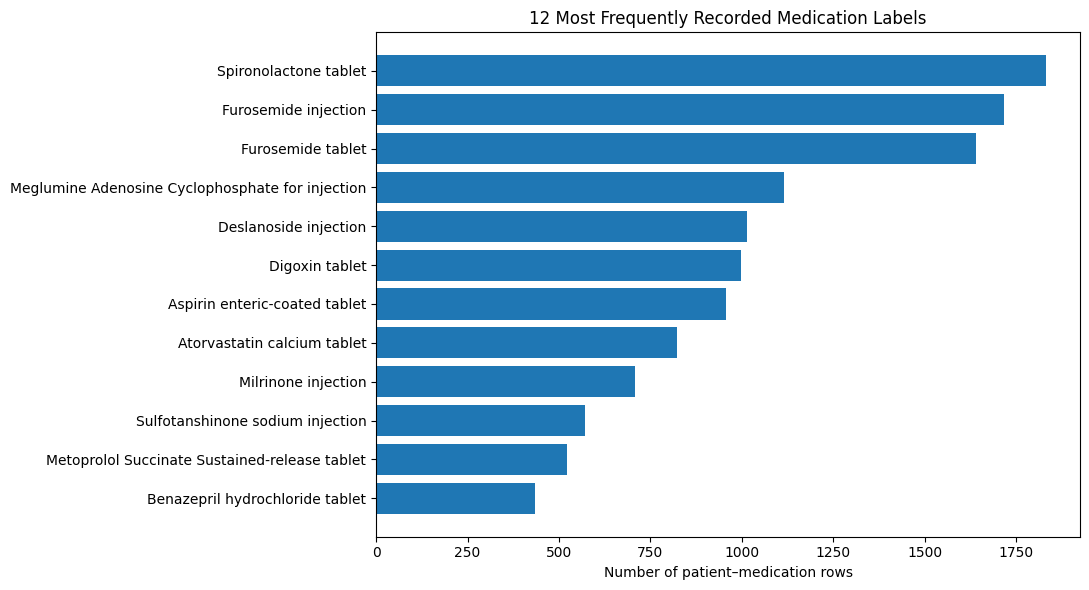

In [32]:
drug_frequency = (
    df["drug_name"].value_counts()
      .rename_axis("drug_name")
      .reset_index(name="medication_rows")
)
drug_frequency["percent_of_medication_rows"] = (
    drug_frequency["medication_rows"] / len(df) * 100).round(2)

lower_labels = df["drug_name"].str.lower()
form_counts = pd.Series({
    "injection_keyword_rows": int(lower_labels.str.contains("injection", regex=False).sum()),
    "tablet_keyword_rows": int(lower_labels.str.contains("tablet", regex=False).sum()),
    "other_keyword_rows": int((~lower_labels.str.contains("injection|tablet", regex=True)).sum()),
})

print("Drug category frequency (top 10):")
display(drug_frequency.head(10))
print("Form keywords in labels:")
display(form_counts.to_frame("medication_rows"))

# Plot rows, not dosage or patient outcome.
chart = drug_frequency.head(12).iloc[::-1]
plt.figure(figsize=(11, 6))
plt.barh(chart["drug_name"], chart["medication_rows"])
plt.xlabel("Number of patient–medication rows")
plt.title("12 Most Frequently Recorded Medication Labels")
plt.tight_layout()
plt.show()

**Actual Insight:** `Spironolactone tablet` is the most frequently recorded label (**1,833 patient–medication rows**), followed by `Furosemide injection` (**1,718**) and `Furosemide tablet` (**1,641**). Label keywords identify **6,290 injection rows** and **9,072 tablet rows**, without making clinical claims about dosing.

### 3.11. Check numeric outliers and missing-value policy

**Reason:** The only numeric field is a patient identifier, not a physiological measurement. 

In [66]:
# Explicit cleaning decisions: no arbitrary row filters or imputation.
# No patient IDs or drug records are replaced with 0 or a guessed drug label.
print("\n Number of clinical numeric measurement columns: 0")
print("\n Remaining missing cells:", int(df.isna().sum().sum()))
print("\n Retained medication rows:", len(df))
print("\n Retained distinct inpatients:", int(df["inpatient_number"].nunique()))
print("\n Retained distinct drug categories:", int(df["drug_name"].nunique()))


 Number of clinical numeric measurement columns: 0

 Remaining missing cells: 0

 Retained medication rows: 15362

 Retained distinct inpatients: 2007

 Retained distinct drug categories: 25


**Actual Insight:** There is **no clinically meaningful numeric outlier-cleaning task in this two-column file**.

### 3.12. Validate cleaned table against the untouched source

**Reason:** Before exporting, show that IDs and row order are preserved, every source medication maps to one cleaned medication, and no duplicate patient–medication pairs were introduced by capitalization or whitespace normalization.

In [34]:
# Check preservation of all patient–medication records.
assert len(df) == len(df_original) - exact_duplicate_rows
assert df.columns.tolist() == df_original.columns.tolist()
assert df["inpatient_number"].reset_index(drop=True).equals(
    df_original.loc[~df_original.duplicated(), "inpatient_number"].reset_index(drop=True))
assert int(df.isna().sum().sum()) == 0
assert int(df.duplicated(["inpatient_number", "drug_name"]).sum()) == 0
assert df["drug_name"].nunique() == df_original["drug_name"].nunique()

validation_df = pd.DataFrame([
    ("Patient–drug rows", len(df_original), len(df)),
    ("Distinct inpatients", df_original["inpatient_number"].nunique(), df["inpatient_number"].nunique()),
    ("Distinct medication labels", df_original["drug_name"].nunique(), df["drug_name"].nunique()),
    ("Missing cells", int(df_original.isna().sum().sum()), int(df.isna().sum().sum())),
    ("Exact duplicate rows", exact_duplicate_rows, int(df.duplicated().sum())),
    ("Labels starting with lowercase", case_rows_before,
     int(df["drug_name"].str.match(r"^[a-z]", na=False).sum())),
], columns=["Metric", "Before Cleaning", "After Cleaning"])
display(validation_df)
print("All preservation and data-quality checks passed.")

,Metric,Before Cleaning,After Cleaning
0,Patient–drug rows,15362,15362
1,Distinct inpatients,2007,2007
2,Distinct medication labels,25,25
3,Missing cells,0,0
4,Exact duplicate rows,0,0
5,Labels starting with lowercase,1130,0


All preservation and data-quality checks passed.


**Actual Insight:** The **15,362 patient–medication rows**, **2,007 inpatients**, and **25 labels** remain. Missing cells and exact duplicate pairs stay at **0**. The **1,130 lowercase-start labels** are now standardized; no relationships have been lost.

## 4. File Output

**Reason:** Save the cleaned table and separately named supporting reports; leave the raw CSV unchanged. The reports document remaining missing values, drug frequencies, per-patient medication counts, and the cleaning decisions.

In [67]:
# Save the cleaned dataset and supporting reports

# Create the output folder if it does not exist
output_folder.mkdir(exist_ok=True)

# Save the cleaned dataset
df.to_csv(
    output_folder / "Team7_CodeAvengers_Category1_DataCleaning_patient_precriptions.csv",
    index=False
)

print("\nOutput Folder:\n ", output_folder)
print("\n Final Cleaned Dataset Shape:", df.shape)


Output Folder:
  C:\Users\swith\OneDrive\Desktop\Swithi\Numpy Ninja\Python Hackathon Sept 2026\Python_Hackathon_Sep_2026\cardiac_failure\cleaned_data

 Final Cleaned Dataset Shape: (15362, 2)


In [70]:
# Build a column-level missingness comparison.
missing_report = pd.DataFrame({
    "column": df.columns,
    "original_missing_count": [int(df_original[col].isna().sum()) for col in df.columns],
    "original_missing_percent": [round(df_original[col].isna().mean() * 100, 2)
                                 for col in df.columns],
    "cleaned_missing_count": [int(df[col].isna().sum()) for col in df.columns],
    "cleaned_missing_percent": [round(df[col].isna().mean() * 100, 2)
                                for col in df.columns],
})

summary = {
    "source_file": "patient_precriptions.csv",
    "original_rows": int(df_original.shape[0]),
    "original_columns": int(df_original.shape[1]),
    "cleaned_rows": int(df.shape[0]),
    "cleaned_columns": int(df.shape[1]),
    "original_distinct_inpatients": int(df_original["inpatient_number"].nunique()),
    "cleaned_distinct_inpatients": int(df["inpatient_number"].nunique()),
    "original_drug_categories": int(df_original["drug_name"].nunique()),
    "cleaned_drug_categories": int(df["drug_name"].nunique()),
    "exact_duplicate_rows_removed": int(exact_duplicate_rows),
    "original_missing_cells": int(df_original.isna().sum().sum()),
    "cleaned_missing_cells": int(df.isna().sum().sum()),
    "medication_rows_with_capitalization_corrected": int(case_rows_before),
    "whitespace_affected_rows": int(whitespace_format_rows),
    "rows_removed_for_outliers_or_missingness": 0,
    "cleaning_decision": "Preserve all valid patient–drug pairs; standardize first-letter capitalization only."
}

prefix = "Team7_CodeAvengers_Category1_DataCleaning_patient_precriptions"
file_paths = {
    "cleaned": output_folder / f"{prefix}.csv",
    "missing_report": output_folder / f"{prefix}_missing_report.csv",
    "drug_frequency": output_folder / f"{prefix}_drug_frequency.csv",
    "patient_counts": output_folder / f"{prefix}_patient_counts.csv",
    "summary": output_folder / f"{prefix}_summary.json",
}

df.to_csv(file_paths["cleaned"], index=False)
missing_report.to_csv(file_paths["missing_report"], index=False)
drug_frequency.to_csv(file_paths["drug_frequency"], index=False)
patient_medication_counts.to_csv(file_paths["patient_counts"], index=False)
with open(file_paths["summary"], "w", encoding="utf-8") as file:
    json.dump(summary, file, indent=4, ensure_ascii=False)

for label, path in file_paths.items():
    print(f"\n {label}: {path}")


 cleaned: C:\Users\swith\OneDrive\Desktop\Swithi\Numpy Ninja\Python Hackathon Sept 2026\Python_Hackathon_Sep_2026\cardiac_failure\cleaned_data\Team7_CodeAvengers_Category1_DataCleaning_patient_precriptions.csv

 missing_report: C:\Users\swith\OneDrive\Desktop\Swithi\Numpy Ninja\Python Hackathon Sept 2026\Python_Hackathon_Sep_2026\cardiac_failure\cleaned_data\Team7_CodeAvengers_Category1_DataCleaning_patient_precriptions_missing_report.csv

 drug_frequency: C:\Users\swith\OneDrive\Desktop\Swithi\Numpy Ninja\Python Hackathon Sept 2026\Python_Hackathon_Sep_2026\cardiac_failure\cleaned_data\Team7_CodeAvengers_Category1_DataCleaning_patient_precriptions_drug_frequency.csv

 patient_counts: C:\Users\swith\OneDrive\Desktop\Swithi\Numpy Ninja\Python Hackathon Sept 2026\Python_Hackathon_Sep_2026\cardiac_failure\cleaned_data\Team7_CodeAvengers_Category1_DataCleaning_patient_precriptions_patient_counts.csv

 summary: C:\Users\swith\OneDrive\Desktop\Swithi\Numpy Ninja\Python Hackathon Sept 2026\P

**Actual Insight:** Five output files are generated with **non-colliding filenames**: the cleaned medication table, missing-value audit, drug-frequency report, patient-medication-count report, and before/after JSON summary.

### 4a. Re-open the exported CSV

**Reason:** A successful `to_csv()` call is not sufficient evidence that the output is readable. Reload the saved file and compare the important values with the in-memory cleaned table.

In [39]:
exported = pd.read_csv(file_paths["cleaned"], low_memory=False)
assert exported.shape == df.shape
assert exported["inpatient_number"].tolist() == df["inpatient_number"].tolist()
assert exported["drug_name"].tolist() == df["drug_name"].astype(str).tolist()
print("Verified cleaned output:", file_paths["cleaned"].name)
print("Rows:", len(exported), "Columns:", exported.shape[1])
display(exported.head())

Verified cleaned output: Team7_CodeAvengers_Category1_DataCleaning_patient_precriptions.csv
Rows: 15362 Columns: 2


,inpatient_number,drug_name
0,857781,Sulfotanshinone sodium injection
1,857781,Furosemide tablet
2,857781,Enoxaparin Sodium injection
3,857781,Meglumine Adenosine Cyclophosphate for injection
4,857781,Furosemide injection


**Actual Insight:** The reloaded cleaned CSV matches the in-memory table: **15,362 rows × 2 columns** with the patient IDs and medication names preserved after export.

## 5. Final Result – Conclusion

The cleaned prescriptions dataset retains **every recorded patient–medication relationship**, changes only the presentation of three lowercase-start medication labels, and preserves tablet versus injection labels as separate records. The output is ready for medication-frequency summaries and joins on `inpatient_number` after checking ID coverage against the team’s patient-level dataset. The **2,007** IDs in this file cannot on their own establish why a patient might be absent compared with an external dataset. Do not infer dose, timing, treatment effectiveness, or medication adherence from these two fields.
